In [1]:
!wget https://raw.githubusercontent.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/master/dataset.py
!wget https://github.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/raw/master/dataset/Data_hoda_full.mat -P dataset

--2026-06-23 19:11:29--  https://raw.githubusercontent.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/master/dataset.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 917 [text/plain]
Saving to: ‘dataset.py.1’

dataset.py.1        100%[===================>]     917  --.-KB/s    in 0s      

2026-06-23 19:11:29 (29.3 MB/s) - ‘dataset.py.1’ saved [917/917]

--2026-06-23 19:11:29--  https://github.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/raw/master/dataset/Data_hoda_full.mat
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/mas

In [1]:
import os

print(os.getcwd())
print(os.listdir())

/mnt/e/Deep Learning/src/Model Subclassing - Autoencoders - Generative Adversarial Networks (GANs)
['AutoEncoder_anomaly.ipynb', 'Convolotional_AutoEncoder.ipynb', 'Introduction_to_Autoencoders.ipynb', 'Simple_GAN.ipynb', 'Upsampling_AytoEncoder.ipynb', 'U_Net.ipynb', 'wget-log']


In [2]:
import sys
sys.path.append("/mnt/e/Deep Learning")

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input, Activation, LeakyReLU
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
from keras.models import Model

from data.dataset import load_hoda

In [4]:
X_train, y_train, X_test, y_test = load_hoda()

In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0, 109, 255, 255, 109,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 172, 247, 255, 255, 247, 172,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,  66, 232, 248, 255, 255, 255, 255, 182,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  66, 232, 232,
        133,   0],
       [  0, 127, 232, 255, 255, 255, 255, 255, 127,  23,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0, 127, 232, 255, 255,
        241, 223],
       [  0, 146, 255, 255, 255, 255, 224,  71,  18,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  31, 183, 237, 255, 255, 255,
        163,  41],
       [  0, 146, 255, 255, 255, 167,  43,   7,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,  88, 212, 248, 255, 255, 255, 255,
        146,   0],
       [19

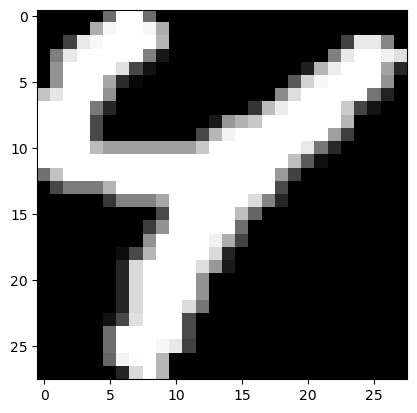

In [7]:
plt.imshow(X_train[0], cmap='gray')

In [8]:

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape : (0,)
y_test shape : (0,)


In [9]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

In [10]:
np.random.seed(42)
randomDIM = 100

In [33]:
X_train = np.astype(X_train, np.float32)
X_train = (X_train - 127.5) / 127.5   #(-1, 1)
X_train = X_train.reshape((-1, 28*28))

print(X_train.shape)

(60000, 784)


In [34]:
X_train.min(), X_train.max()

(np.float32(-1.0078431), np.float32(0.99215686))

# Create Generator

In [42]:
gen_model = Sequential()
gen_model.add(Input(shape=(randomDIM,)))
gen_model.add(Dense(256, kernel_initializer=tf.keras.initializers.RandomNormal(mean=0, stddev=0.02)))
gen_model.add(LeakyReLU(negative_slope=0.2))
gen_model.add(Dense(512))
gen_model.add(LeakyReLU(0.2))
gen_model.add(Dense(1024))
gen_model.add(LeakyReLU(0.2))
gen_model.add(Dense(28*28, activation='tanh'))

In [43]:
gen_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 784)            │       803,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 0 (0.00 B)

# Create Discriminator

In [44]:
dis_model = Sequential()
dis_model.add(Input(shape=(28*28, )))
dis_model.add(Dense(1024))
dis_model.add(LeakyReLU(0.2))
dis_model.add(Dropout(0.2))
dis_model.add(Dense(512))
dis_model.add(LeakyReLU(0.2))
dis_model.add(Dropout(0.2))
dis_model.add(Dense(256))
dis_model.add(LeakyReLU(0.2))
dis_model.add(Dropout(0.2))
dis_model.add(Dense(1, activation='sigmoid'))

dis_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,460,225 (5.57 MB)

 Trainable params: 1,460,225 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
dis_loss = BinaryCrossentropy()
gan_opt = Adam(learning_rate=0.0002, beta_1=0.5)
dis_opt = Adam(learning_rate=0.0002, beta_1=0.5)

dis_model.compile(optimizer=dis_opt,
                  loss=dis_loss)

# Combined Model GAN

In [46]:
dis_model.trainable = False

input = Input(shape=(randomDIM, ))
x = gen_model(input)
output = dis_model(x)

GAN_model = Model(input, output)

GAN_model.summary()

Model: "functional_70"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 784)            │     1,486,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 1)              │     1,460,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,946,577 (11.24 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 1,460,225 (5.57 MB)

In [47]:
GAN_model.compile(optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
                  loss=BinaryCrossentropy)

In [48]:
num_epochs = 200
batch_size = 128

disc_losses_epoch = []
gan_losses_epoch = []

for epoch in range(num_epochs):

    print(f"Epoch {epoch+1}")
    print("-" * 100)

    num_batch = int(np.ceil(X_train.shape[0] / batch_size))

    d_losses_batch = []
    g_losses_batch = []

    for i in range(num_batch):

        images_batch = X_train[i * batch_size:(i + 1) * batch_size]

        current_batch_size = images_batch.shape[0]

        random_vec = np.random.normal(
            0,
            1,
            size=(current_batch_size, randomDIM)
        )

        fake_images_batch = gen_model.predict(
            random_vec,
            verbose=0
        )

        dis_model.trainable = True

        concat_images = np.concatenate(
            [fake_images_batch, images_batch],
            axis=0
        )

        labels_batch = np.zeros((2 * current_batch_size,))
        labels_batch[current_batch_size:] = 0.9

        d_loss = dis_model.train_on_batch(
            concat_images,
            labels_batch
        )

        d_losses_batch.append(d_loss)

        dis_model.trainable = False

        random_vec = np.random.normal(
            0,
            1,
            size=(current_batch_size, randomDIM)
        )

        y_gan = np.ones((current_batch_size,))

        g_loss = GAN_model.train_on_batch(
            random_vec,
            y_gan
        )

        g_losses_batch.append(g_loss)

    epoch_disc_loss = np.mean(d_losses_batch)
    epoch_gan_loss = np.mean(g_losses_batch)

    disc_losses_epoch.append(epoch_disc_loss)
    gan_losses_epoch.append(epoch_gan_loss)

    print(
        f"D Loss: {epoch_disc_loss:.4f} | "
        f"G Loss: {epoch_gan_loss:.4f}"
    )

Epoch 1
----------------------------------------------------------------------------------------------------
D Loss: 0.3967 | G Loss: 2.1319
Epoch 2
----------------------------------------------------------------------------------------------------
D Loss: 0.2797 | G Loss: 4.3343
Epoch 3
----------------------------------------------------------------------------------------------------
D Loss: 0.2638 | G Loss: 4.7025
Epoch 4
----------------------------------------------------------------------------------------------------
D Loss: 0.2629 | G Loss: 4.5872
Epoch 5
----------------------------------------------------------------------------------------------------
D Loss: 0.2668 | G Loss: 4.4292
Epoch 6
----------------------------------------------------------------------------------------------------
D Loss: 0.2743 | G Loss: 4.2328
Epoch 7
----------------------------------------------------------------------------------------------------
D Loss: 0.2819 | G Loss: 4.0558
Epoch 8
-----

KeyboardInterrupt: 

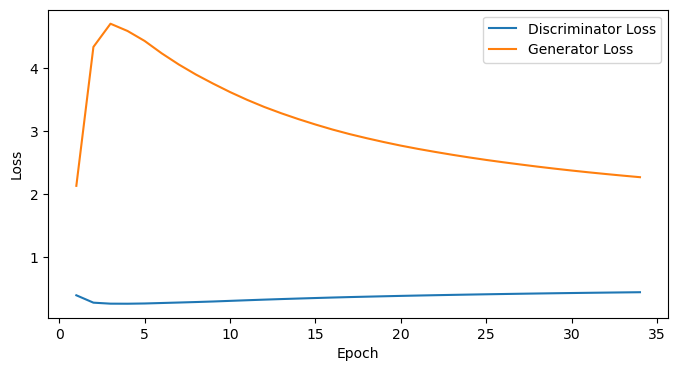

In [64]:
if (epoch + 1) % 35 == 0:
    plt.figure(figsize=(8, 4))

    plt.plot(
        range(1, len(disc_losses_epoch) + 1),
        disc_losses_epoch,
        label='Discriminator Loss'
    )

    plt.plot(
        range(1, len(gan_losses_epoch) + 1),
        gan_losses_epoch,
        label='Generator Loss'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [49]:
random_vec = np.random.normal(
    0,
    1,
    size=(current_batch_size, randomDIM)
)

In [55]:
gen_images = gen_model.predict(random_vec)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [56]:
gen_images.shape

(128, 784)

In [57]:
gen_images = gen_images.reshape(-1, 28, 28, 1)

In [58]:
gen_images[0].shape

(28, 28, 1)

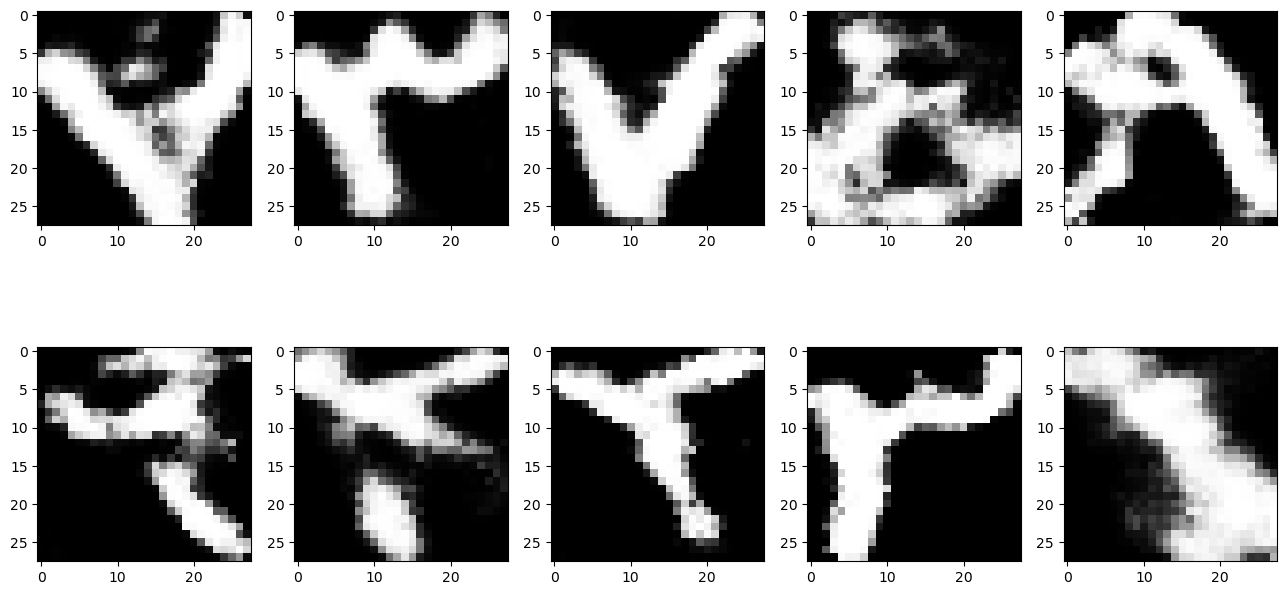

<Figure size 640x480 with 0 Axes>

In [63]:
plt.figure(figsize=(16, 8))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(gen_images[i], cmap='gray')
plt.show()
plt.tight_layout()